# Placement Predictor
## Student Placement Prediction using Machine Learning

### Internship Project

Developed by:
Aditya Verma 

Technology Used:
- Python
- Scikit-Learn
- Pandas
- NumPy
- Matplotlib
- Logistic Regression

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

import pickle


# Step 1: Load the Dataset

The dataset is loaded into a Pandas DataFrame to perform data analysis and preprocessing.

In [26]:
df = pd.read_csv("../data/raw/college_student_placement_dataset.csv")

# Step 2: Display the Dataset

Display the first five rows of the dataset to understand its structure.

In [27]:
df.head()

,College_ID,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement
0,CLG0030,107,6.61,6.28,8,No,8,8,4,No
1,CLG0061,97,5.52,5.37,8,No,7,8,0,No
2,CLG0036,109,5.36,5.83,9,No,3,1,1,No
3,CLG0055,122,5.47,5.75,6,Yes,1,6,1,No
4,CLG0004,96,7.91,7.69,7,No,8,10,2,No


# Step 3: Dataset Information

Let's understand the number of rows, columns, data types, and statistical summary.

In [28]:
df.shape

(10000, 10)

In [29]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   College_ID              10000 non-null  str    
 1   IQ                      10000 non-null  int64  
 2   Prev_Sem_Result         10000 non-null  float64
 3   CGPA                    10000 non-null  float64
 4   Academic_Performance    10000 non-null  int64  
 5   Internship_Experience   10000 non-null  str    
 6   Extra_Curricular_Score  10000 non-null  int64  
 7   Communication_Skills    10000 non-null  int64  
 8   Projects_Completed      10000 non-null  int64  
 9   Placement               10000 non-null  str    
dtypes: float64(2), int64(5), str(3)
memory usage: 894.3 KB


In [30]:
df.describe()

,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Extra_Curricular_Score,Communication_Skills,Projects_Completed
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,99.471800,7.535673,7.532379,5.546400,4.970900,5.561800,2.513400
std,15.053101,1.447519,1.470141,2.873477,3.160103,2.900866,1.715959
min,41.000000,5.000000,4.540000,1.000000,0.000000,1.000000,0.000000
25%,89.000000,6.290000,6.290000,3.000000,2.000000,3.000000,1.000000
50%,99.000000,7.560000,7.550000,6.000000,5.000000,6.000000,3.000000
75%,110.000000,8.790000,8.770000,8.000000,8.000000,8.000000,4.000000
max,158.000000,10.000000,10.460000,10.000000,10.000000,10.000000,5.000000


# Step 4: Check Missing Values

Missing values can reduce model performance, so we identify them before preprocessing.

In [31]:
df.isnull().sum()

College_ID                0
IQ                        0
Prev_Sem_Result           0
CGPA                      0
Academic_Performance      0
Internship_Experience     0
Extra_Curricular_Score    0
Communication_Skills      0
Projects_Completed        0
Placement                 0
dtype: int64

# Step 5: Check Duplicate Records

Duplicate records may introduce bias, so we check and remove them if necessary.

In [32]:
df.duplicated().sum()

np.int64(0)

In [33]:
df = df.drop_duplicates()

# Step 6: Analyze the Target Variable

Examine the distribution of the placement status.

In [34]:
df["Placement"].value_counts()

Placement
No     8341
Yes    1659
Name: count, dtype: int64

# Step 7: Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) helps us understand the dataset by examining the distribution of variables, identifying patterns, and detecting relationships between features before building the machine learning model.

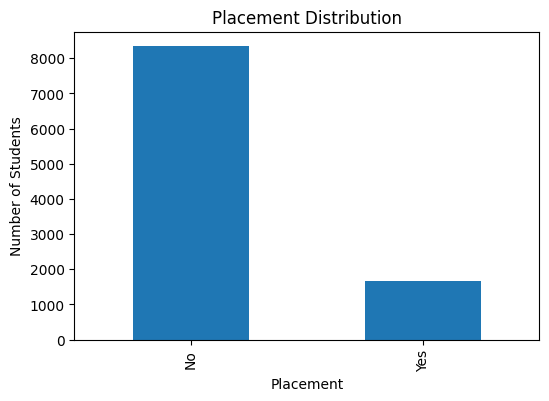

In [35]:
plt.figure(figsize=(6,4))

df["Placement"].value_counts().plot(kind="bar")

plt.title("Placement Distribution")
plt.xlabel("Placement")
plt.ylabel("Number of Students")

plt.show()

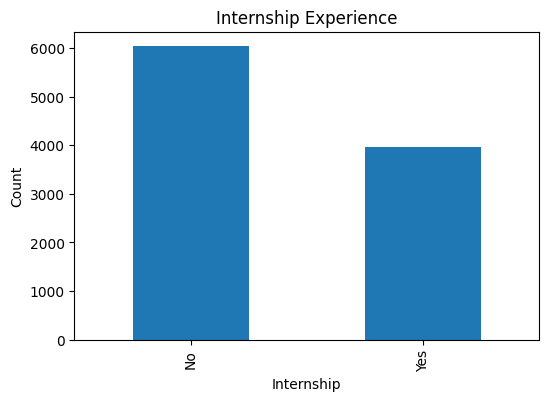

In [36]:
plt.figure(figsize=(6,4))

df["Internship_Experience"].value_counts().plot(kind="bar")

plt.title("Internship Experience")
plt.xlabel("Internship")
plt.ylabel("Count")

plt.show()

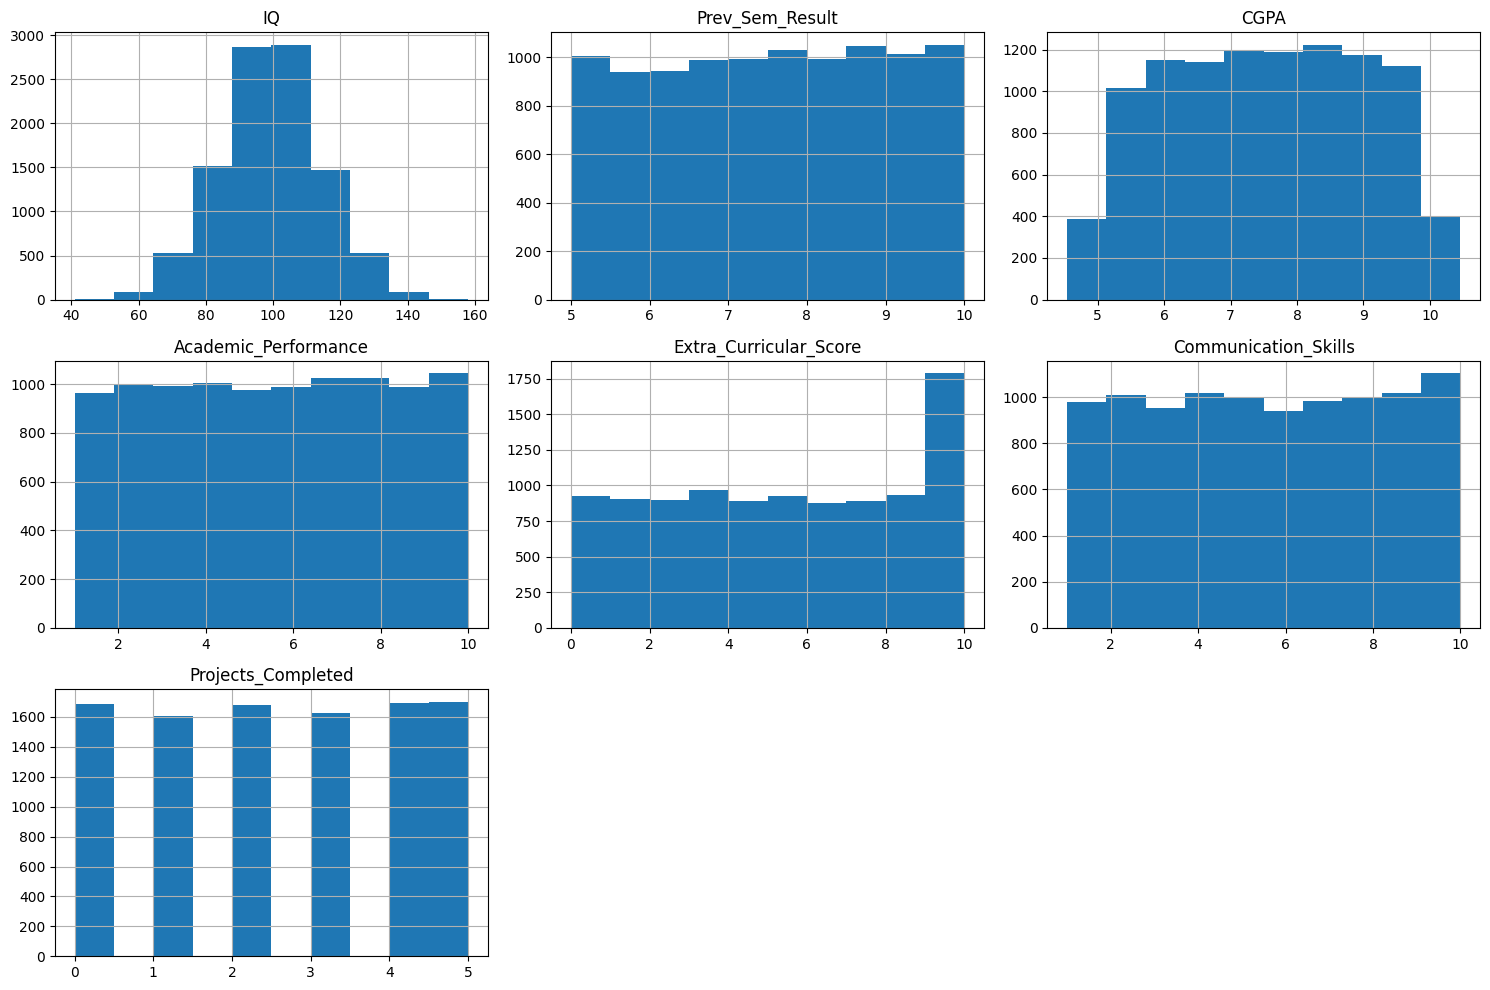

In [37]:
df.hist(figsize=(15,10))

plt.tight_layout()

plt.show()

# Step 8: Correlation Analysis

Correlation analysis helps identify the relationship between numerical features. A heatmap makes it easier to visualize strong positive or negative correlations.

In [38]:
correlation = df.drop("College_ID", axis=1).corr(numeric_only=True)

correlation


,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Extra_Curricular_Score,Communication_Skills,Projects_Completed
IQ,1.000000,-0.002640,-0.002859,-0.006827,-0.003458,-0.010896,0.014538
Prev_Sem_Result,-0.002640,1.000000,0.980768,-0.005765,0.009326,-0.017269,0.018434
CGPA,-0.002859,0.980768,1.000000,-0.002958,0.011441,-0.018242,0.020872
Academic_Performance,-0.006827,-0.005765,-0.002958,1.000000,0.011774,-0.019733,-0.013148
Extra_Curricular_Score,-0.003458,0.009326,0.011441,0.011774,1.000000,0.003769,0.008122
Communication_Skills,-0.010896,-0.017269,-0.018242,-0.019733,0.003769,1.000000,-0.004486
Projects_Completed,0.014538,0.018434,0.020872,-0.013148,0.008122,-0.004486,1.000000


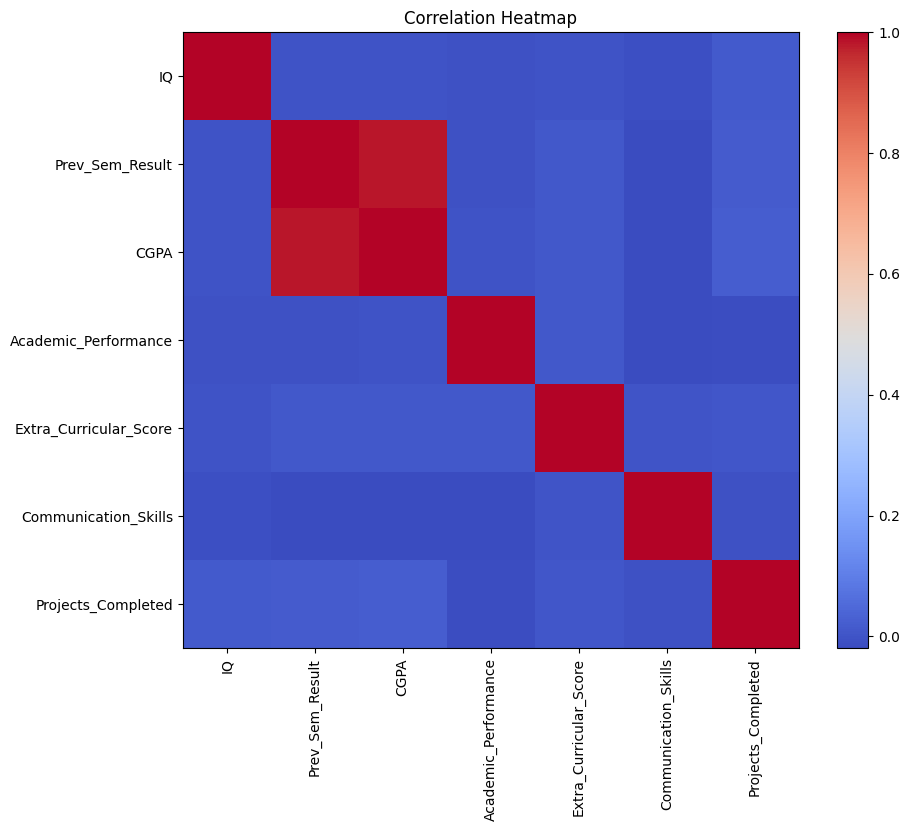

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

plt.imshow(correlation, cmap="coolwarm", interpolation="nearest")

plt.colorbar()

plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=90)

plt.yticks(range(len(correlation.columns)), correlation.columns)

plt.title("Correlation Heatmap")

plt.show()

# Step 9: Data Preprocessing

Before training the model, we preprocess the dataset by removing unnecessary columns and converting categorical values into numerical form. This ensures the data is suitable for machine learning algorithms.

In [40]:
# Remove unnecessary ID column
df = df.drop("College_ID", axis=1)

# Convert categorical columns into numerical values
df["Internship_Experience"] = df["Internship_Experience"].map({
    "Yes": 1,
    "No": 0
})

df["Placement"] = df["Placement"].map({
    "Yes": 1,
    "No": 0
})

# Display updated data types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   IQ                      10000 non-null  int64  
 1   Prev_Sem_Result         10000 non-null  float64
 2   CGPA                    10000 non-null  float64
 3   Academic_Performance    10000 non-null  int64  
 4   Internship_Experience   10000 non-null  int64  
 5   Extra_Curricular_Score  10000 non-null  int64  
 6   Communication_Skills    10000 non-null  int64  
 7   Projects_Completed      10000 non-null  int64  
 8   Placement               10000 non-null  int64  
dtypes: float64(2), int64(7)
memory usage: 703.3 KB


# Step 10: Separate Features and Target Variable

The dataset is divided into input features (**X**) and the target variable (**y**). The model will learn from the features to predict the placement status.

In [41]:
X = df.drop("Placement", axis=1)
y = df["Placement"]
print(X.columns)

Index(['IQ', 'Prev_Sem_Result', 'CGPA', 'Academic_Performance',
       'Internship_Experience', 'Extra_Curricular_Score',
       'Communication_Skills', 'Projects_Completed'],
      dtype='str')


# Step 11: Split the Dataset

The dataset is split into training and testing sets. The training set is used to train the model, while the testing set is used to evaluate its performance.

In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Step 12: Feature Scaling

Feature scaling standardizes the numerical values so that all features contribute equally during model training. This is especially important for Logistic Regression.

In [43]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Step 13: Train the Logistic Regression Model

The Logistic Regression algorithm is trained using the training dataset to learn the relationship between student attributes and placement outcomes.

In [44]:
model = LogisticRegression(random_state=42)

model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

# Step 14: Make Predictions

After training the model, we use it to predict the placement status of students in the testing dataset.

In [45]:
y_pred = model.predict(X_test)

y_pred

array([1, 0, 0, ..., 1, 0, 0], shape=(2000,))

# Step 15: Evaluate Model Performance

The model's performance is evaluated using Accuracy Score, Confusion Matrix, and Classification Report.

In [46]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9035


# Step 16: Confusion Matrix

The confusion matrix shows the number of correct and incorrect predictions made by the model.

In [47]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[1609   65]
 [ 128  198]]


In [48]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.96      0.94      1674
           1       0.75      0.61      0.67       326

    accuracy                           0.90      2000
   macro avg       0.84      0.78      0.81      2000
weighted avg       0.90      0.90      0.90      2000



# Step 17: Save the Trained Model

The trained Logistic Regression model is saved as a `.pkl` file so it can be reused for future predictions without retraining.

In [49]:
import pickle

with open("../models/placement_model.pkl", "wb") as file:
    pickle.dump(model, file)

print("Model saved successfully!")

Model saved successfully!


# Step 18: Save the Feature Scaler

The feature scaler is saved to ensure that future input data is transformed in the same way as the training data before making predictions.

In [50]:
with open("../models/scaler.pkl", "wb") as file:
    pickle.dump(scaler, file)

print("Scaler saved successfully!")

Scaler saved successfully!


# Step 19: Load the Saved Model

The saved Logistic Regression model is loaded from disk to verify that it can be used for future predictions.

In [51]:
with open("../models/placement_model.pkl", "rb") as file:
    loaded_model = pickle.load(file)

print("Model loaded successfully!")

Model loaded successfully!


In [62]:
new_student = pd.DataFrame({
    "IQ": [115],
    "Prev_Sem_Result": [8.2],
    "CGPA": [8.5],
    "Academic_Performance": [8],
    "Internship_Experience": [1],
    "Extra_Curricular_Score": [8],
    "Communication_Skills": [9],
    "Projects_Completed": [4]
})

new_student_scaled = scaler.transform(new_student)

prediction = loaded_model.predict(new_student_scaled)

if prediction[0] == 1:
    print("Prediction: Student is likely to be Placed")
else:
    print("Prediction: Student is likely to be Not Placed")

Prediction: Student is likely to be Placed


# Step 20: Predict Placement Probability

The Logistic Regression model estimates the probability of both placement and non-placement for the given student.

In [53]:
probability = loaded_model.predict_proba(new_student_scaled)

print(f"Probability of Not Placed: {probability[0][0]*100:.2f}%")
print(f"Probability of Placed: {probability[0][1]*100:.2f}%")

Probability of Not Placed: 0.00%
Probability of Placed: 100.00%


# Step 21: Conclusion

This project successfully developed a Logistic Regression model to predict student placement based on academic performance, internship experience, communication skills, and other relevant features. The model demonstrates how machine learning can assist educational institutions in identifying students who may need additional guidance and support to improve their placement opportunities.

# Step 22: Future Scope

This project can be further enhanced by:

- Deploying the model as a web application using Flask or Streamlit.
- Training the model with a larger and more diverse dataset.
- Incorporating additional student attributes for improved prediction.
- Performing hyperparameter tuning to optimize model performance.
- Integrating the model into a college placement management system.

# Step 23: Feature Importance

The coefficients of the Logistic Regression model indicate how each feature influences the placement prediction. Positive coefficients increase the likelihood of placement, while negative coefficients decrease it.

In [54]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

feature_importance = feature_importance.sort_values(by="Coefficient", ascending=False)

feature_importance

,Feature,Coefficient
6,Communication_Skills,1.863173
0,IQ,1.614292
2,CGPA,1.592335
7,Projects_Completed,1.172291
1,Prev_Sem_Result,0.206867
4,Internship_Experience,0.020554
3,Academic_Performance,-0.028780
5,Extra_Curricular_Score,-0.032756


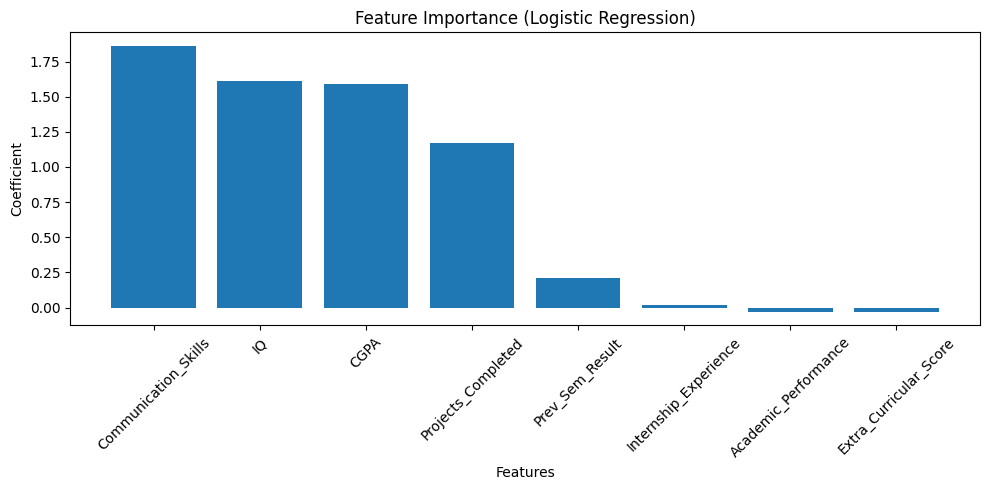

In [55]:
plt.figure(figsize=(10, 5))

plt.bar(feature_importance["Feature"], feature_importance["Coefficient"])

plt.xticks(rotation=45)
plt.xlabel("Features")
plt.ylabel("Coefficient")
plt.title("Feature Importance (Logistic Regression)")
plt.tight_layout()

plt.show()

In [61]:
%who

LogisticRegression	 StandardScaler	 X	 X_test	 X_train	 accuracy	 accuracy_score	 classification_report	 cm	 
confusion_matrix	 correlation	 df	 feature_importance	 file	 loaded_model	 model	 new_student	 new_student_scaled	 
np	 pd	 pickle	 plt	 prediction	 predictions	 probability	 scaler	 train_test_split	 
y	 y_pred	 y_test	 y_train	 
